# Feature Analysis for Stock Return Prediction

This notebook analyzes the effectiveness of the generated features for predicting the **percentage change (Return)** of Taiwan stocks.

We will use:
1.  **Correlation Heatmap**: To see which features are linearly correlated with the target.
2.  **Feature Importance (Random Forest)**: To see which features are most useful for a non-linear tree-based model.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Add src to path
sys.path.insert(0, os.path.abspath('src'))

from Feature_Engineering import prepare_training_data

## 1. Load Data with Return as Target

We set `target_col='Return'` to predict the percentage change.

In [2]:
STOCK_ID = "2330" # TSMC

# Prepare data: Target is Next Day's Return
df = prepare_training_data(STOCK_ID, path= "data/twstock.db")

if df is None or df.empty:
    print("Error: No data found. Please check if the database exists and has data for this stock.")
else:
    print(f"Data Shape: {df.shape}")
    display(df.head())

Data Shape: (1150, 91)


,Stock_ID,Open,High,Low,Close,Volume,Type,SMA_5,SMA_10,SMA_20,...,Volume_Lag_18,Return_Lag_18,Close_Lag_19,Volume_Lag_19,Return_Lag_19,Close_Lag_20,Volume_Lag_20,Return_Lag_20,Future_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2021-05-04,2330,588.0,594.0,582.0,591.0,40273595,TW,598.2,598.8,603.85,...,24603109.0,0.013289,602.0,43091157.0,0.025554,587.0,38790886.0,-0.016750,0.013536,2
2021-05-05,2330,594.0,594.0,585.0,585.0,29254785,TW,593.2,597.1,603.00,...,23976625.0,0.004918,610.0,24603109.0,0.013289,602.0,43091157.0,0.025554,0.006838,2
2021-05-06,2330,590.0,590.0,580.0,587.0,30725590,TW,590.2,596.6,601.85,...,27303862.0,-0.004894,613.0,23976625.0,0.004918,610.0,24603109.0,0.013289,-0.027257,1
2021-05-07,2330,594.0,600.0,589.0,599.0,28075722,TW,590.0,597.4,601.15,...,22606128.0,-0.008197,610.0,27303862.0,-0.004894,613.0,23976625.0,0.004918,-0.065109,0
2021-05-10,2330,596.0,597.0,588.0,589.0,20434079,TW,590.2,596.1,600.10,...,25971622.0,0.000000,605.0,22606128.0,-0.008197,610.0,27303862.0,-0.004894,-0.071307,0


## 2. Correlation Analysis (Heatmap)

We calculate the correlation of all features with the `Target` (Next Day Return). 
Since there are many features (80+), we will plot the **Top 20 features** with the highest absolute correlation.

Top 20 Features by Correlation with Target:
Future_Return    0.924322
Volume_Lag_9     0.101422
Volume           0.074431
Volume_Lag_8     0.073641
Volume_Lag_10    0.073087
ATR              0.068386
BB_Width         0.059682
SMA_60           0.058975
Volume_Lag_1     0.057556
BB_Upper         0.056649
Close_Lag_3      0.056526
Close_Lag_2      0.056248
Stoch_D          0.055924
Close_Lag_4      0.055424
SMA_5            0.054472
Close_Lag_5      0.054212
EMA_26           0.053768
Close_Lag_1      0.053555
Close_Lag_16     0.053265
EMA_12           0.052935
Name: Target, dtype: float64


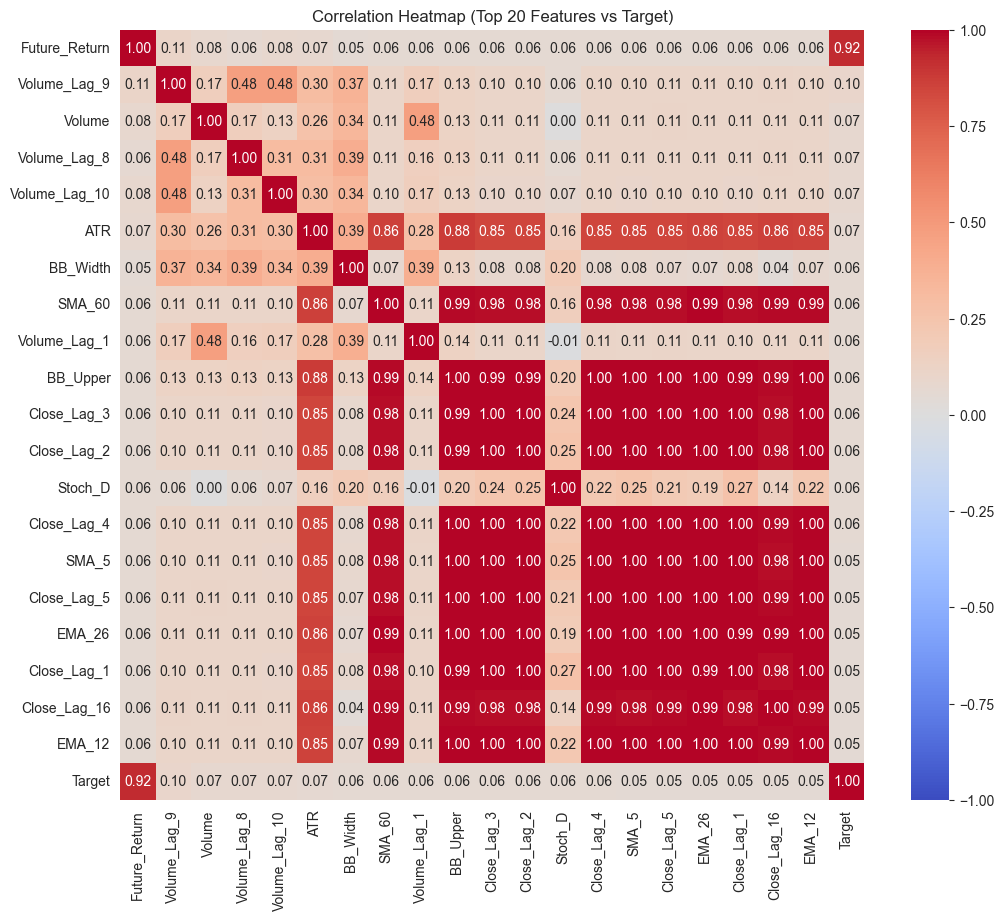

In [3]:
if df is not None and not df.empty:
    df = df.drop(columns=['Stock_ID', 'Type'])
    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Get correlation with Target
    target_corr = corr_matrix['Target'].drop('Target') # Drop target itself

    # Sort by absolute correlation
    top_features = target_corr.abs().sort_values(ascending=False).head(20)
    top_features_names = top_features.index.tolist()

    print("Top 20 Features by Correlation with Target:")
    print(target_corr[top_features_names])

    # Plot Heatmap of these top features
    plt.figure(figsize=(12, 10))
    top_corr_matrix = df[top_features_names + ['Target']].corr()
    sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap (Top 20 Features vs Target)")
    plt.show()

### Analysis of Correlation
- **High Correlation**: Indicates a strong linear relationship. If `Return_Lag_1` is high, it means momentum exists.
- **Low Correlation**: Doesn't mean the feature is useless! It might have a non-linear relationship captured by complex models.

## 3. Feature Importance (Random Forest)

Linear correlation misses non-linear patterns. A Random Forest model can tell us which features are actually used to split the data and reduce variance.

C:\Users\bc261\AppData\Local\Temp\ipykernel_43580\3693738185.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


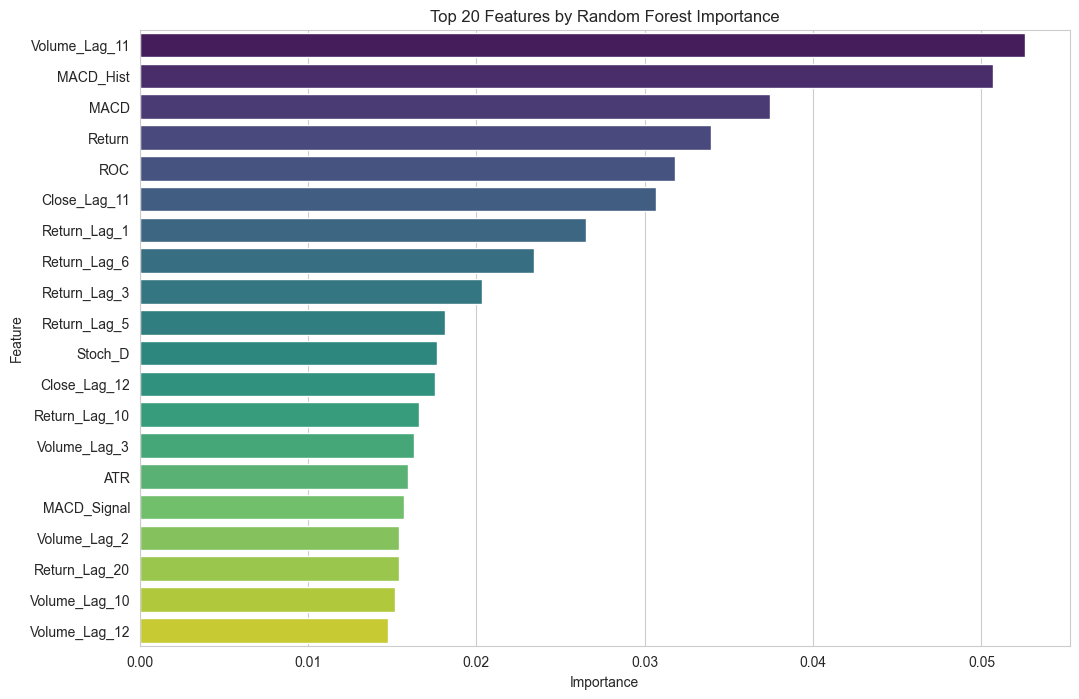

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

if df is not None and not df.empty:
    # Prepare X and y
    X = df.drop(columns=['Target'])
    y = df['Target']

    # Split data (Time Series split: Train on past, Test on future)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Get Feature Importances
    importances = rf.feature_importances_
    feature_names = X.columns

    # Create DataFrame for plotting
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title("Top 20 Features by Random Forest Importance")
    plt.show()

## 4. Conclusion

By comparing the **Correlation Heatmap** and **Random Forest Importance**, we can identify the most robust features.

- Features that appear in **both** lists are likely very strong predictors.
- Features only in **Random Forest** list likely have complex, non-linear relationships with the price change.
- **Lag Features** (e.g., `Return_Lag_1`, `Volume_Lag_1`) often show high importance in time-series prediction.

## 5. Feature Documentation

Here is a detailed explanation of all the features generated by our `Feature_Engineering.py` script.

### A. Raw Data (5 Features)
These are the raw values from the stock market.
*   **Open, High, Low, Close**: Daily price data.
*   **Volume**: Number of shares traded.

### B. Trend Indicators (9 Features)
Used to identify the direction of the market trend.
*   **SMA_5, SMA_10, SMA_20, SMA_60**: Simple Moving Averages. Average price over the last N days.
    *   *Usage*: Identify support/resistance levels and trend direction.
*   **EMA_12, EMA_26**: Exponential Moving Averages. Give more weight to recent prices.
    *   *Usage*: More responsive to recent price changes than SMA.
*   **MACD**: Moving Average Convergence Divergence. `EMA_12 - EMA_26`.
*   **MACD_Signal**: 9-day EMA of MACD.
*   **MACD_Hist**: `MACD - MACD_Signal`.
    *   *Usage*: Identify momentum changes and potential buy/sell signals (crossovers).

### C. Momentum Indicators (5 Features)
Used to determine the strength of the price movement and overbought/oversold conditions.
*   **RSI (Relative Strength Index)**: Measures the speed and change of price movements (0-100).
    *   *Usage*: >70 Overbought (potential sell), <30 Oversold (potential buy).
*   **Stoch_K, Stoch_D (KD)**: Stochastic Oscillator. Compares closing price to price range over time.
    *   *Usage*: Similar to RSI, identifies turning points.
*   **ROC (Rate of Change)**: Percentage change in price over N days.
    *   *Usage*: Measures the velocity of price change.
*   **Williams %R**: Momentum indicator that measures overbought and oversold levels.
    *   *Usage*: Similar to Stochastic Oscillator.

### D. Volatility Indicators (4 Features)
Used to measure how much the price is fluctuating.
*   **BB_Upper, BB_Lower**: Bollinger Bands. `SMA_20 +/- 2 * StdDev`.
*   **BB_Width**: `(Upper - Lower) / SMA_20`.
    *   *Usage*: Measures volatility. Squeeze (low width) often precedes a breakout.
*   **ATR (Average True Range)**: Measures market volatility by decomposing the entire range of an asset price for that period.
    *   *Usage*: Often used for setting stop-loss levels.

### E. Volume Indicators (1 Feature)
*   **OBV (On-Balance Volume)**: Cumulative volume based on price direction.
    *   *Usage*: Confirms price trends. Divergence between price and OBV can signal reversals.

### F. Pattern Features (2 Features)
*   **Bullish_Alignment**: Boolean (0 or 1). True if `SMA_5 > SMA_10 > SMA_20 > SMA_60`.
    *   *Usage*: Strong signal of an established uptrend.
*   **MA_Entanglement**: `StdDev(SMAs) / Close`.
    *   *Usage*: Measures how close the moving averages are. Low values indicate "entanglement" (consolidation), often preceding a big move.

### G. Lag Features (60 Features)
Historical context for the model.
*   **Close_Lag_1...20**: Closing price 1 to 20 days ago.
*   **Volume_Lag_1...20**: Volume 1 to 20 days ago.
*   **Return_Lag_1...20**: Daily return 1 to 20 days ago.
    *   *Usage*: Allows the model to "see" the past price shape and momentum patterns.